# Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, confusion_matrix

In [2]:
pip install mlflow dagshub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 71.7 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 75.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
import mlflow
import mlflow.sklearn
import dagshub

dagshub.init(repo_owner='adzid23', repo_name='Freeuni_ML_Fraud_Detection', mlflow=True)
mlflow.set_experiment("DecisionTree_Training")

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=72f18cf1-256c-466f-abe3-219ceca82319&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=697975f4043463a9c7d84629ff6e917090be2874db0677e593cf966c37c682ca




Accessing as adzid23

Initialized MLflow to track repo "adzid23/Freeuni_ML_Fraud_Detection"

Repository adzid23/Freeuni_ML_Fraud_Detection initialized!

2026/05/03 20:16:24 INFO mlflow.tracking.fluent: Experiment with name 'DecisionTree_Training' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/5734685d5fc74c099e2c0ba5de72902c', creation_time=1777839385058, experiment_id='2', last_update_time=1777839385058, lifecycle_stage='active', name='DecisionTree_Training', tags={}, trace_location=None, workspace='default'>

# Data Loading & Cleaning

In [4]:
DATA_PATH = '/kaggle/input/competitions/ieee-fraud-detection'

train_transaction = pd.read_csv(f'{DATA_PATH}/train_transaction.csv')
train_identity    = pd.read_csv(f'{DATA_PATH}/train_identity.csv')

df = train_transaction.merge(train_identity, on='TransactionID', how='left')

y = df['isFraud']
X = df.drop(columns=['isFraud', 'TransactionID'])

null_frac     = X.isnull().mean()
cols_to_drop  = null_frac[null_frac > 0.5].index.tolist()
X = X.drop(columns=cols_to_drop)
X = X.drop(columns=['TransactionDT'], errors='ignore')

print(f"Shape after merge: {df.shape}")
print(f"Dropped {len(cols_to_drop)} high-null columns")
print(f"Shape after cleaning: {X.shape}")

with mlflow.start_run(run_name="DT_Cleaning"):
    mlflow.log_params({
        "null_threshold": 0.5,
        "dropped_cols": len(cols_to_drop),
    })
    mlflow.log_metric("cols_after_cleaning", X.shape[1])

Shape after merge: (590540, 434)
Dropped 214 high-null columns
Shape after cleaning: (590540, 217)
🏃 View run DT_Cleaning at: https://dagshub.com/adzid23/Freeuni_ML_Fraud_Detection.mlflow/#/experiments/2/runs/209738d24ce547978c6cd3de4e69fdb7
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Fraud_Detection.mlflow/#/experiments/2


# Feature Engineering

In [5]:
with mlflow.start_run(run_name="DT_Feature_Engineering"):

    X['hour'] = (df['TransactionDT'] // 3600) % 24
    X['day']  = (df['TransactionDT'] // (3600 * 24)) % 7
    X['TransactionAmt_log'] = np.log1p(df['TransactionAmt'])

    cat_cols = X.select_dtypes(include='object').columns.tolist()
    for col in cat_cols:
        freq_map = X[col].value_counts(normalize=True).to_dict()
        X[col] = X[col].map(freq_map).fillna(0)

    print(f"Encoded {len(cat_cols)} categorical columns")
    print(f"Shape after feature engineering: {X.shape}")

    mlflow.log_params({
        "time_features": "hour, day",
        "log_transform": "TransactionAmt",
        "cat_encoding": "frequency",
        "cat_cols_encoded": len(cat_cols)
    })
    mlflow.log_metric("total_features", X.shape[1])

Encoded 9 categorical columns
Shape after feature engineering: (590540, 220)
🏃 View run DT_Feature_Engineering at: https://dagshub.com/adzid23/Freeuni_ML_Fraud_Detection.mlflow/#/experiments/2/runs/6f92ecf7a705432ba6023910b5bca702
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Fraud_Detection.mlflow/#/experiments/2


# Feature Selection

In [6]:
with mlflow.start_run(run_name="DT_Feature_Selection"):

    num_cols     = X.select_dtypes(include=[np.number]).columns.tolist()
    low_var_cols = [c for c in num_cols if X[c].std() < 0.01]
    X = X.drop(columns=low_var_cols)
    print(f"Dropped {len(low_var_cols)} near-constant columns")

    corr_matrix   = X.corr().abs()
    upper         = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    high_corr_cols = [c for c in upper.columns if any(upper[c] > 0.9)]
    X = X.drop(columns=high_corr_cols)
    print(f"Dropped {len(high_corr_cols)} highly correlated columns")
    print(f"Final feature count: {X.shape[1]}")

    mlflow.log_params({
        "variance_threshold": 0.01,
        "correlation_threshold": 0.9,
    })
    mlflow.log_metric("dropped_low_var", len(low_var_cols))
    mlflow.log_metric("dropped_high_corr", len(high_corr_cols))
    mlflow.log_metric("features_selected", X.shape[1])

Dropped 2 near-constant columns
Dropped 102 highly correlated columns
Final feature count: 116
🏃 View run DT_Feature_Selection at: https://dagshub.com/adzid23/Freeuni_ML_Fraud_Detection.mlflow/#/experiments/2/runs/571d46cf661545868ca48d72b33e8dc1
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Fraud_Detection.mlflow/#/experiments/2


# Training

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (472432, 116) | Test: (118108, 116)


## Run 1 - Baseline (max_depth=5)

In [9]:
with mlflow.start_run(run_name="DT_Baseline"):

    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model',   DecisionTreeClassifier(
            max_depth=5,
            class_weight='balanced',
            random_state=42
        ))
    ])

    pipeline.fit(X_train, y_train)

    train_auc = roc_auc_score(y_train, pipeline.predict_proba(X_train)[:, 1])
    test_auc  = roc_auc_score(y_test,  pipeline.predict_proba(X_test)[:, 1])
    gap       = train_auc - test_auc

    print(f"Train AUC: {train_auc:.4f}")
    print(f"Test  AUC: {test_auc:.4f}")
    print(f"Gap:       {gap:.4f}")

    mlflow.log_params({
        "max_depth": 5,
        "class_weight": "balanced",
    })
    mlflow.log_metric("train_auc", train_auc)
    mlflow.log_metric("test_auc",  test_auc)
    mlflow.log_metric("overfit_gap", gap)

Train AUC: 0.8358
Test  AUC: 0.8323
Gap:       0.0035
🏃 View run DT_Baseline at: https://dagshub.com/adzid23/Freeuni_ML_Fraud_Detection.mlflow/#/experiments/2/runs/456921207f4e4d4c9f54609f2bf27f6e
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Fraud_Detection.mlflow/#/experiments/2


## Run 2 - max_depth sweep (overfitting vs underfitting analysis)

depth=   2 | train=0.7191 | test=0.7204 | gap=-0.0013
depth=   4 | train=0.8206 | test=0.8190 | gap=0.0016
depth=   6 | train=0.8499 | test=0.8427 | gap=0.0073
depth=   8 | train=0.8763 | test=0.8606 | gap=0.0157
depth=  10 | train=0.9024 | test=0.8688 | gap=0.0336
depth=  15 | train=0.9547 | test=0.8554 | gap=0.0993
depth=  20 | train=0.9811 | test=0.8322 | gap=0.1488
depth=None | train=1.0000 | test=0.7682 | gap=0.2318


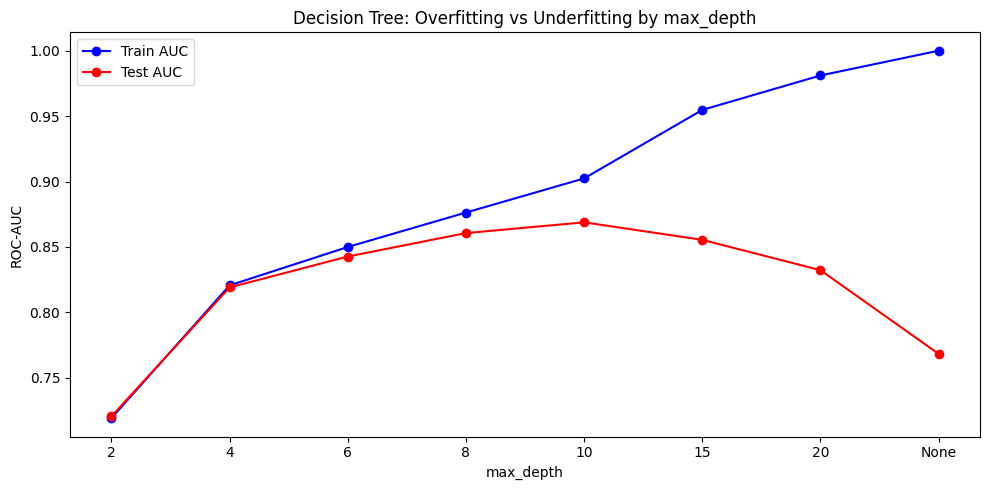

🏃 View run DT_Depth_Sweep at: https://dagshub.com/adzid23/Freeuni_ML_Fraud_Detection.mlflow/#/experiments/2/runs/8e347776c5b84900b660b6016b73e776
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Fraud_Detection.mlflow/#/experiments/2


In [10]:
with mlflow.start_run(run_name="DT_Depth_Sweep"):

    results = []

    for depth in [2, 4, 6, 8, 10, 15, 20, None]:

        pipe = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('model',   DecisionTreeClassifier(
                max_depth=depth,
                class_weight='balanced',
                random_state=42
            ))
        ])

        pipe.fit(X_train, y_train)

        train_auc = roc_auc_score(y_train, pipe.predict_proba(X_train)[:, 1])
        test_auc  = roc_auc_score(y_test,  pipe.predict_proba(X_test)[:, 1])
        gap       = train_auc - test_auc

        depth_label = str(depth) if depth is not None else "None"
        results.append({'depth': depth_label, 'train_auc': train_auc, 'test_auc': test_auc, 'gap': gap})

        mlflow.log_metric("train_auc", train_auc, step=depth if depth else 30)
        mlflow.log_metric("test_auc",  test_auc,  step=depth if depth else 30)

        print(f"depth={depth_label:>4} | train={train_auc:.4f} | test={test_auc:.4f} | gap={gap:.4f}")

    # Plot the results
    results_df = pd.DataFrame(results)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(results_df['depth'], results_df['train_auc'], 'b-o', label='Train AUC')
    ax.plot(results_df['depth'], results_df['test_auc'],  'r-o', label='Test AUC')
    ax.set_xlabel('max_depth')
    ax.set_ylabel('ROC-AUC')
    ax.set_title('Decision Tree: Overfitting vs Underfitting by max_depth')
    ax.legend()
    plt.tight_layout()
    mlflow.log_figure(fig, "depth_sweep.png")
    plt.show()

# Add better features

In [11]:
card1_stats = X_train.groupby('card1')['TransactionAmt'].agg(['mean', 'std']).reset_index()
card1_stats.columns = ['card1', 'card1_amt_mean', 'card1_amt_std']

X_train = X_train.merge(card1_stats, on='card1', how='left')
X_test  = X_test.merge(card1_stats, on='card1', how='left')

card2_stats = X_train.groupby('card2')['TransactionAmt'].agg(['mean', 'std']).reset_index()
card2_stats.columns = ['card2', 'card2_amt_mean', 'card2_amt_std']

X_train = X_train.merge(card2_stats, on='card2', how='left')
X_test  = X_test.merge(card2_stats, on='card2', how='left')

X_train['card1_amt_diff'] = X_train['TransactionAmt'] - X_train['card1_amt_mean']
X_test['card1_amt_diff']  = X_test['TransactionAmt']  - X_test['card1_amt_mean']

print(f"New feature count: {X_train.shape[1]}")

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
New feature count: 121


## Refinement 1 - Retrain with aggregation features

In [12]:
with mlflow.start_run(run_name="DT_With_Aggregation_Features"):

    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model',   DecisionTreeClassifier(
            max_depth=10,
            class_weight='balanced',
            random_state=42
        ))
    ])

    pipe.fit(X_train, y_train)

    train_auc = roc_auc_score(y_train, pipe.predict_proba(X_train)[:, 1])
    test_auc  = roc_auc_score(y_test,  pipe.predict_proba(X_test)[:, 1])

    print(f"Train AUC: {train_auc:.4f}")
    print(f"Test  AUC: {test_auc:.4f}")
    print(f"Gap:       {(train_auc - test_auc):.4f}")

    improvement = test_auc - 0.8688
    print(f"Improvement over baseline: {improvement:+.4f}")

    mlflow.log_params({
        "max_depth": 10,
        "class_weight": "balanced",
        "extra_features": "card1_amt_mean, card1_amt_std, card2_amt_mean, card2_amt_std, card1_amt_diff"
    })
    mlflow.log_metric("train_auc", train_auc)
    mlflow.log_metric("test_auc",  test_auc)
    mlflow.log_metric("overfit_gap", train_auc - test_auc)
    mlflow.log_metric("improvement_over_baseline", improvement)

Train AUC: 0.9028
Test  AUC: 0.8726
Gap:       0.0301
Improvement over baseline: +0.0038
🏃 View run DT_With_Aggregation_Features at: https://dagshub.com/adzid23/Freeuni_ML_Fraud_Detection.mlflow/#/experiments/2/runs/bfa58f10590d4314b85ed33f30cdbe52
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Fraud_Detection.mlflow/#/experiments/2


## Refinement 2 — min_samples_leaf tuning

In [13]:
with mlflow.start_run(run_name="DT_MinSamplesLeaf_Sweep"):

    results = []

    for min_samples in [1, 10, 50, 100, 500, 1000]:

        pipe = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('model',   DecisionTreeClassifier(
                max_depth=10,
                min_samples_leaf=min_samples,
                class_weight='balanced',
                random_state=42
            ))
        ])

        pipe.fit(X_train, y_train)

        train_auc = roc_auc_score(y_train, pipe.predict_proba(X_train)[:, 1])
        test_auc  = roc_auc_score(y_test,  pipe.predict_proba(X_test)[:, 1])
        gap       = train_auc - test_auc

        results.append({'min_samples': min_samples, 'train_auc': train_auc, 'test_auc': test_auc, 'gap': gap})

        mlflow.log_metric("train_auc", train_auc, step=min_samples)
        mlflow.log_metric("test_auc",  test_auc,  step=min_samples)

        print(f"min_samples_leaf={min_samples:>5} | train={train_auc:.4f} | test={test_auc:.4f} | gap={gap:.4f}")

min_samples_leaf=    1 | train=0.9028 | test=0.8726 | gap=0.0301
min_samples_leaf=   10 | train=0.9023 | test=0.8716 | gap=0.0307
min_samples_leaf=   50 | train=0.9009 | test=0.8764 | gap=0.0245
min_samples_leaf=  100 | train=0.8982 | test=0.8789 | gap=0.0193
min_samples_leaf=  500 | train=0.8857 | test=0.8714 | gap=0.0142
min_samples_leaf= 1000 | train=0.8784 | test=0.8655 | gap=0.0129
🏃 View run DT_MinSamplesLeaf_Sweep at: https://dagshub.com/adzid23/Freeuni_ML_Fraud_Detection.mlflow/#/experiments/2/runs/f824d0246d334527bef4d91fd64f3890
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Fraud_Detection.mlflow/#/experiments/2


## Run 4 - Final Model

In [14]:
with mlflow.start_run(run_name="DT_FinalModel"):

    final_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model',   DecisionTreeClassifier(
            max_depth=10,
            min_samples_leaf=100,
            class_weight='balanced',
            random_state=42
        ))
    ])

    final_pipeline.fit(X_train, y_train)

    train_auc = roc_auc_score(y_train, final_pipeline.predict_proba(X_train)[:, 1])
    test_auc  = roc_auc_score(y_test,  final_pipeline.predict_proba(X_test)[:, 1])

    print(f"Train AUC: {train_auc:.4f}")
    print(f"Test  AUC: {test_auc:.4f}")
    print(f"Gap:       {(train_auc - test_auc):.4f}")

    mlflow.log_params({
        "max_depth": 10,
        "min_samples_leaf": 100,
        "class_weight": "balanced",
        "features": "base + card1/card2 aggregations",
        "reason": "best test AUC from depth + min_samples_leaf sweeps"
    })
    mlflow.log_metric("train_auc", train_auc)
    mlflow.log_metric("test_auc",  test_auc)
    mlflow.log_metric("overfit_gap", train_auc - test_auc)

    mlflow.sklearn.log_model(
        final_pipeline,
        artifact_path="dt_fraud_pipeline",
        registered_model_name="DT_Fraud_Pipeline"
    )
    print("Model saved to Model Registry as DT_Fraud_Pipeline")

Train AUC: 0.8982
Test  AUC: 0.8789
Gap:       0.0193


2026/05/03 20:50:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/03 20:50:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'DT_Fraud_Pipeline'.
2026/05/03 20:50:37 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: DT_Fraud_Pipeline, version 1
Created version '1' of model 'DT_Fraud_Pipeline'.


Model saved to Model Registry as DT_Fraud_Pipeline
🏃 View run DT_FinalModel at: https://dagshub.com/adzid23/Freeuni_ML_Fraud_Detection.mlflow/#/experiments/2/runs/3e431c49f6b24d4d85d88c161e7385ca
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Fraud_Detection.mlflow/#/experiments/2
